In [75]:
from notebooks_function import *

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pypsa
import warnings
import country_converter as coco
import os

cc = coco.CountryConverter()


def get_time_series(n, df, df_load, date_time, title):

    start_time = date_time[0]
    end_time = date_time[1]
    
    df_pos = df.clip(lower=0)
    df_neg = df.clip(upper=0)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    df_pos.loc[:,start_time:end_time].T.plot(
        kind="area",
        ax=ax,
        color=[n.carriers.color[c] for c in df_pos.index]
    )
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore", 
            message="Attempting to set identical low and high ylims"
        )
        
        df_neg.loc[:,start_time:end_time].T.plot(
            kind="area",
            ax=ax,
            color=[n.carriers.color[c] for c in df_neg.index],
            legend=False
        )
    
    # Plot load demand (overlaid)
    df_load.loc[start_time:end_time].plot(
        ax=ax,
        color="black",
        linewidth=2,
        style='--',
        alpha=0.8,
    )
    
    # ---- Legend Formatting ----
    handles, labels = ax.get_legend_handles_labels()
    handles, labels = handles[::-1], labels[::-1]  # Reverse for nicer order
    
    # Remove duplicates while preserving order (reversed)
    seen = set()
    unique = [(h, l) for h, l in zip(handles, labels) if l not in seen and not seen.add(l)]
    
    # Unzip the filtered handles and labels
    handles, labels = zip(*unique)
    
    # Replace technical carrier names with nice names if available
    labels = [
        n.carriers.nice_name.get(label, label) #.title()
        for label in labels
    ]
    
    ax.legend(
        handles,
        labels,
        title="Carrier",
        bbox_to_anchor=(1.0, 0.85),
        loc='upper left'
    )
    
    ymax = df_pos.sum().max()
    ymin = df_neg.sum().min()
    
    delta = abs(ymax) * 0.1
    ymin -= delta
    ymax += delta
    
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel("Generation [GW]")
    ax.grid()
    
    result = pd.concat([df_load, df.sum()], axis=1).min(axis=1)
    hourly_matching = round((n.snapshot_weightings.objective @ result) / (n.snapshot_weightings.objective @ df_load) * 100, 2)
    ax.set_title(title + f": {hourly_matching}% Hourly Matching")
    
    fig.tight_layout()

    return fig


# 1 - Retrieve networks

In [7]:
# Main
years = [2025, 2030]
scenarios = ["baseline",
             "energy-match-50",
             "hourly-match-50-90",
             "hourly-match-50-95",
             "hourly-match-50-98",
             "hourly-match-50-99",
             ]

# years = [2025, 2030, 2035, 2040]
# scenarios = ["baseline",
#              "energy-match-25",
#              "hourly-match-25-90",
#              "hourly-match-25-95",
#              "hourly-match-25-98",
#              "hourly-match-25-99",
#              ]

# Sensitivities NOTE: change the folder directory for Sensitivites
# years = [2025, 2030, 2035, 2040]
# scenarios = ["baseline", # Main
#              "hourly-match-noadd-10-99",
#              "hourly-match-noadd-50-99",
#              "hourly-match-noadd-90-99",
#             ]

# years = [2025, 2030]
# scenarios = ["hourly-match-50-99", # Main
#              "hourly-match-co2-price25-50-99",
#              "hourly-match-no-clean-firm-50-99",
#              "hourly-match-no-LDES-50-99",
#              "hourly-match-EU-50-99",
#             ]


# Build MultiIndex
index = pd.MultiIndex.from_product(
    [years, scenarios],
    names=["year", "scenario"]
)

# Create empty DataFrame
df_networks = pd.DataFrame(index=index, columns=["network"])

# Fill it
for year, sc in index:
    try:
        n = pypsa.Network(f"../results/{sc}/networks/base_s_39___{year}.nc")
    except:
        print(f"{sc}-{year} not availabe")
        continue
    n = prepare_network(n)
    n = drop_year(n)
    n.name = f"{sc}-{year}"
    df_networks.loc[(year, sc), "network"] = n

    m = strip_network_GoO(n)
    m.name = "GoO-" + m.name
    df_networks.loc[(year, sc), "GoO"] = m

df_networks = df_networks.dropna()

INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current:

In [8]:
date_time = ('05-01','05-14')
save_fig = False

Index(['01-01 00:00:00', '01-01 03:00:00', '01-01 06:00:00', '01-01 09:00:00',
       '01-01 12:00:00', '01-01 15:00:00', '01-01 18:00:00', '01-01 21:00:00',
       '01-02 00:00:00', '01-02 03:00:00',
       ...
       '12-30 18:00:00', '12-30 21:00:00', '12-31 00:00:00', '12-31 03:00:00',
       '12-31 06:00:00', '12-31 09:00:00', '12-31 12:00:00', '12-31 15:00:00',
       '12-31 18:00:00', '12-31 21:00:00'],
      dtype='object', name='snapshot', length=2920)

-------------------------------------Analyzing Albania


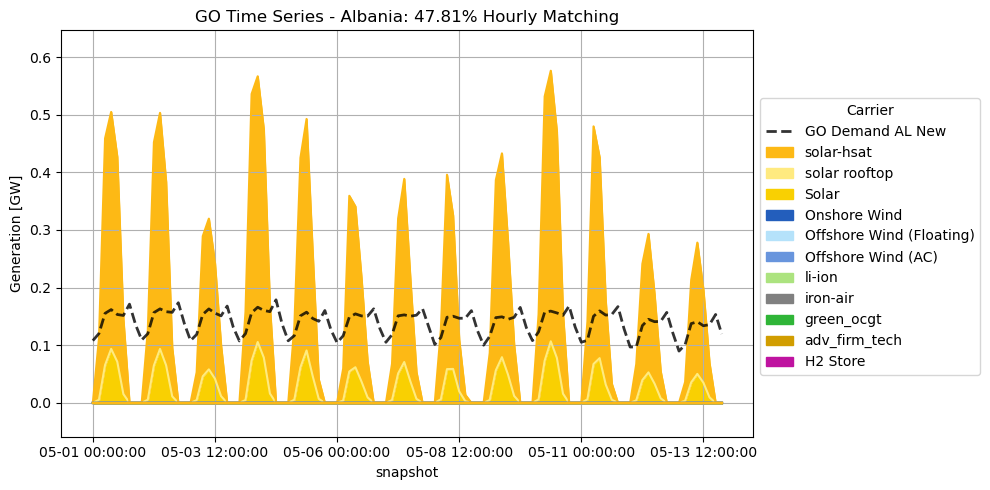

In [76]:
# Precompute GoO stats
df_GoO, _ = get_stats_all(
    df_networks["GoO"], 
    "energy_balance", 
    groupby=["country", "carrier"], 
    aggregate_time=False
)

# Get sorted list of countries, excluding empty strings
countries = sorted(set(df_networks.iloc[0, 0].buses.country.unique()) - {""})

fig_base_path = "figures/GoO_time_series/country"

for country in countries:
    cc_name = cc.convert(country, to="short_name")
    
    if save_fig:
        country_fig_path = os.path.join(fig_base_path, cc_name)
        os.makedirs(country_fig_path, exist_ok=True)

    print(f"-------------------------------------Analyzing {cc_name}")

    for year, scenario in df_networks.index:
        if scenario == "baseline":
            continue

        title_fig = f"GO Time Series - {scenario} - {cc_name}"

        # Filter and clean data
        df_balance = clean_virtual_names(df_GoO[(year, scenario)])
        df_country = df_balance.xs(country, level="country").groupby("carrier").sum()
        df_country = df_country[df_country.index != "GoO"] * 1e-3

        # Load GO demand
        m = df_networks.loc[(year, scenario), "GoO"]
        df_load = m.loads_t.p_set[f"GO Demand {country} New"] * 1e-3

        # Generate and save figure
        fig = get_time_series(
            m, 
            df_country,
            df_load,
            date_time, 
            title=f"GO Time Series - {cc_name}"
        )

        if save_fig:
            fig.savefig(os.path.join(country_fig_path, f"{title_fig}.png"), dpi=300, bbox_inches="tight")

-------------------------------------Analyzing Albania


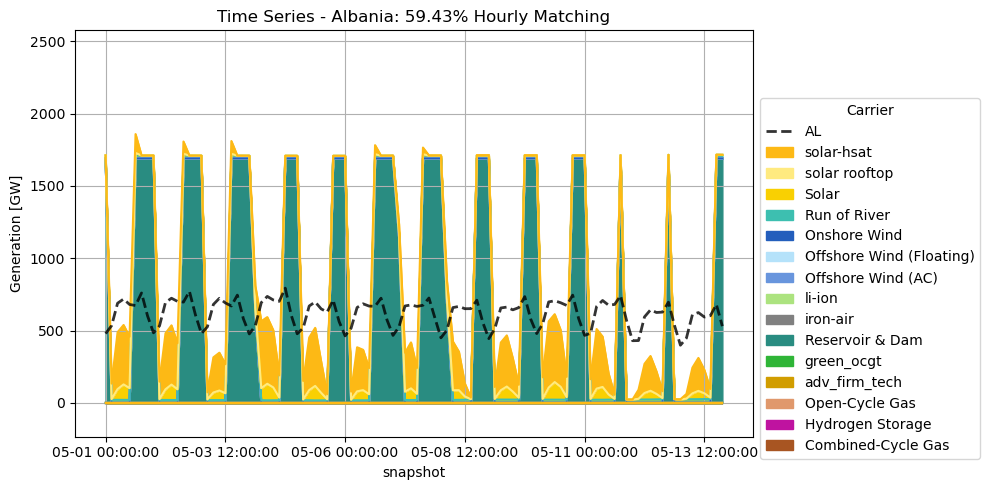

In [77]:
elec_demand = [
    "electricity",
    "land transport EV",
    "industry electricity",
    "agriculture electricity",
    "agriculture machinery electric",
]

# Get statistics
df, _ = get_stats_all(
    df_networks["network"], 
    "energy_balance", 
    groupby=["country","bus_carrier","carrier"], 
    aggregate_time=False
)

df_load_all, _ = get_stats_all(
    df_networks["network"], 
    "energy_balance", 
    groupby=["country"], 
    components=["Load"], 
    carrier=elec_demand, 
    aggregate_time=False
)

# Get sorted list of countries excluding empty strings
countries = sorted(set(df_networks.iloc[0, 0].buses.country.unique()) - {""})

fig_base_path = "figures/time_series/country"

for country in countries:
    cc_name = cc.convert(country, to="short_name")

    if save_fig:
        country_fig_path = os.path.join(fig_base_path, cc_name)
        os.makedirs(country_fig_path, exist_ok=True)

    print(f"-------------------------------------Analyzing {cc_name}")

    for year, scenario in df_networks.index:
        if scenario == "baseline":
            continue

        title_fig = f"Time Series - {scenario} - {cc_name}"

        # Filter df for country and relevant bus_carrier/carrier
        df_balance = df[(year, scenario)]
        df_balance = df_balance.xs(country, level="country")
        df_balance = df_balance[
            df_balance.index.get_level_values("bus_carrier").isin(["AC", "low voltage"])
            & ~df_balance.index.get_level_values("carrier").isin([
                "AC", "DC", "electricity", "low voltage", 
                "electricity distribution grid", "BEV charger",
                "home battery charger", "home battery discharger"
            ])
        ]

        # Aggregate by carrier
        df_country = df_balance.groupby("carrier").sum()
        df_country = df_country.rename(index=grouping_storage).groupby("carrier").sum()

        # Get country load
        df_load = -df_load_all[(year, scenario)].groupby("country").sum().loc[country]

        # Generate figure
        fig = get_time_series(
            m, 
            df_country,
            df_load,
            date_time, 
            title=f"Time Series - {cc_name}"
        )

        if save_fig:
            fig.savefig(os.path.join(country_fig_path, f"{title_fig}.png"), dpi=300, bbox_inches="tight")